# Global Model Synthesis

This notebook implements a **global synthesis model** that integrates features and diagnostics generated by the rolling surrogate regime analysis into a single, stable analytical view.

While the rolling surrogate workflow is designed to detect and characterize local regime shifts, this global model is designed to:
- summarize system behavior across all observed regimes,
- extract persistent, cross-regime structure,
- and provide a consistent reference frame against which local deviations can be interpreted.

The two notebooks are therefore complementary:
- the rolling surrogate analysis focuses on *change, drift, and regime structure*,
- the global model focuses on *aggregation, comparison, and long-horizon structure*.

---

## Conceptual Role

The global model answers a different class of questions than the rolling surrogate:

- *Which features matter consistently across regimes?*
- *Which signals explain long-term variation rather than transient fluctuations?*
- *How do different regimes relate to one another in a lower-dimensional representation?*
- *Which combinations of features define typical, atypical, or extreme system states?*

Rather than treating the system as a sequence of local behaviors, the global model treats it as a **population of states** and attempts to characterize the geometry and structure of that population.

---

## Analytical Structure

The workflow proceeds in four stages:

### 1. Feature Integration
The per-run feature table generated by the rolling analysis is loaded and cleaned.

This includes:
- selecting relevant features,
- handling missing values,
- normalizing or standardizing where appropriate,
- and optionally engineering composite or interaction features.

The result is a consistent, analysis-ready feature matrix spanning all runs.

---

### 2. Dimensionality Reduction and Structure Discovery
High-dimensional feature spaces are projected into lower-dimensional representations (e.g., via PCA or related methods) to reveal dominant axes of variation.

This supports:
- visualization of system state distributions,
- identification of clusters, gradients, or outliers,
- and reasoning about relationships between regimes.

These projections are descriptive tools rather than predictive models.

---

### 3. Global Predictive Modeling
A single global model is fit across all runs to capture long-horizon explanatory structure.

Unlike the rolling surrogate models, this model is:
- trained on the full dataset,
- optimized for stability rather than sensitivity,
- and used to understand persistent drivers rather than regime transitions.

Feature importance, partial dependence, or similar diagnostics are used to interpret global relationships.

---

### 4. Regime Comparison and Contextualization
Outputs from the rolling analysis (regime labels, instability flags, or local driver changes) are merged with the global representations.

This allows:
- comparison of regimes in the same latent space,
- identification of which regimes are structurally similar or distinct,
- and interpretation of local changes in the context of global structure.

---

## Design Principles

- **Complementarity:** The global model does not replace the rolling analysis; it contextualizes it.
- **Stability over sensitivity:** The global model prioritizes robustness and interpretability over responsiveness to short-term change.
- **Geometry over sequence:** The system is analyzed as a distribution of states, not primarily as a time series.
- **Interpretability over optimization:** Emphasis is placed on understanding structure rather than maximizing predictive accuracy.

---

## Summary

The global model provides a long-horizon, integrative view of system behavior that complements the regime-aware rolling surrogate analysis.

Together, the two workflows support a multi-scale understanding of complex, evolving systems:
- the rolling analysis detects and explains *when and how the system changes*,
- the global model explains *what the system is, in aggregate*.

This dual perspective enables both operational awareness and structural understanding, without requiring strong mechanistic assumptions or fixed regime definitions.

## How To Read This Notebook

This notebook begins after the rolling surrogate workflow has converted raw runs into an analysis-ready feature table. Its role is different from the rolling notebook: the rolling analysis asks what is changing locally, while this notebook asks what remains structurally important across the full operating history.

The emphasis is stable interpretation rather than prediction alone. Feature selection, dimensionality reduction, model fitting, and explanation are all used to identify drivers that remain informative despite drift, noise, and changing local regimes.


In [1]:
# Dependency verification and imports for the global model pipeline.
import sys, subprocess, importlib.util, warnings

REQUIRED_PACKAGES = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.11",
    "sklearn": "scikit-learn>=1.3",
    "shap": "shap>=0.44",
    "lime": "lime>=0.2.0.1",
}

for import_name, package_spec in REQUIRED_PACKAGES.items():
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {package_spec}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", package_spec])

from pathlib import Path
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from IPython.display import display

from scipy.stats import (
    pearsonr,
    spearmanr,
    kendalltau,
    mannwhitneyu,
)

from sklearn.preprocessing import (
    StandardScaler,
    PowerTransformer,
    QuantileTransformer,
    OneHotEncoder,
)
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
)

from sklearn.linear_model import (
    ElasticNetCV,
    LogisticRegressionCV,
)

from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    IsolationForest,
)

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    roc_auc_score,
    balanced_accuracy_score,
)

from sklearn.covariance import MinCovDet

import shap
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings("ignore", category=FutureWarning)
print("Dependency check complete.")

Dependency check complete.


## Starting Point: The Rolling Feature Table

The primary input is `pipeline_outputs/features/feature_table.csv`, created by the Rolling Surrogate Regime Analysis notebook. Each row represents one run, and columns include time-series summaries, coupling features, run-level metadata, categorical context, treatment-like metrics, external metrics, and the target response.

Because this notebook starts from the rolling feature table, it assumes the raw time-series alignment and run-level featurization steps have already been completed.


In [2]:
# Inputs and shared schema.
FEATURE_DIR = Path("pipeline_outputs/features")
FEATURE_FILE = "feature_table.csv"
FEATURE_TABLE_PATH = FEATURE_DIR / FEATURE_FILE

GLOBAL_OUTPUT_DIR = FEATURE_DIR.parent / "global_model_outputs"
GLOBAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MANIFEST_PATH = FEATURE_DIR / "pipeline_manifest.json"
if MANIFEST_PATH.exists():
    with open(MANIFEST_PATH, "r", encoding="utf-8") as handle:
        PIPELINE_MANIFEST = json.load(handle)
else:
    PIPELINE_MANIFEST = {}

RUN_ID_COL = PIPELINE_MANIFEST.get("run_id_column", "run_id")
DATE_COL = PIPELINE_MANIFEST.get("date_column", "run_start_date")
TARGET_COL = PIPELINE_MANIFEST.get("target_column", "target_metric_primary")

USER_START_DATE = None
earliest_date = pd.to_datetime(USER_START_DATE, errors="coerce")

MANUAL_RUN_METADATA_CSV = Path("pipeline_inputs/manual_run_metrics.csv")
manual_cols_to_add = [
    "feature_20",
    "feature_4_1_dwell_median",
    "feature_4_1_dwell_delta",
]
prefix_manual_cols = "manual__"

df = pd.read_csv(FEATURE_TABLE_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

if pd.notna(earliest_date):
    df = df.loc[df[DATE_COL] >= earliest_date].copy()

if RUN_ID_COL not in df.columns:
    raise ValueError(f"Feature table must contain '{RUN_ID_COL}'.")

df[RUN_ID_COL] = df[RUN_ID_COL].astype(str).str.strip()

if MANUAL_RUN_METADATA_CSV.exists():
    manual_df = pd.read_csv(MANUAL_RUN_METADATA_CSV)
    if RUN_ID_COL not in manual_df.columns:
        raise ValueError(f"Manual metrics file must contain '{RUN_ID_COL}'.")

    manual_df[RUN_ID_COL] = manual_df[RUN_ID_COL].astype(str).str.strip()

    if manual_cols_to_add == ["ALL"]:
        cols = [col for col in manual_df.columns if col != RUN_ID_COL]
    else:
        missing = [col for col in manual_cols_to_add if col not in manual_df.columns]
        if missing:
            raise ValueError(f"Requested manual columns not found: {missing}")
        cols = manual_cols_to_add

    manual_sel = manual_df[[RUN_ID_COL] + cols].drop_duplicates(RUN_ID_COL, keep="first").set_index(RUN_ID_COL)
    if prefix_manual_cols:
        manual_sel = manual_sel.rename(columns={col: f"{prefix_manual_cols}{col}" for col in cols})
        added_cols = [f"{prefix_manual_cols}{col}" for col in cols]
    else:
        added_cols = cols

    df = df.join(manual_sel, on=RUN_ID_COL)
    n_filled = df[added_cols].notna().any(axis=1).sum() if added_cols else 0
    print(f"Joined manual metrics: added {len(added_cols)} columns; {n_filled}/{len(df)} rows filled.")
else:
    print(f"Manual metrics file not found at {MANUAL_RUN_METADATA_CSV}; continuing without it.")

missing_tokens = {"nan": np.nan, "": np.nan, "NA": np.nan, "N/A": np.nan, "null": np.nan, "None": np.nan}

for col in df.columns:
    if df[col].dtype == "object":
        series = df[col].astype(str)
        if series.str.contains("%", na=False).any():
            df[col] = series.str.strip().str.replace("%", "", regex=False).replace(missing_tokens)
            df[col] = pd.to_numeric(df[col], errors="coerce")

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print(f"Final shape: {df.shape}")
display(df.head())

Manual metrics file not found at pipeline_inputs/manual_run_metrics.csv; continuing without it.
Final shape: (120, 141)


,run_id,feature_1_setpoint,run_start_date,unit_label,group_label,total_run_days,feature_12,feature_13,feature_14,feature_15,...,feature_9_slope_WINDOW_2,feature_9_slope_WINDOW_3,cai_f1_over_f3_WINDOW_1,cai_f1_over_f3_WINDOW_2,cai_f1_over_f3_WINDOW_3,target_metric_primary,feature_16,feature_17,feature_18,feature_19
0,RUN_001,62.000000,2025-01-06,GR01,group_3,13.541667,0.58916,6.35117,cat_b,type_z,...,0.000063,-0.000010,0.148667,0.090061,0.089384,0.04075,1.07154,0.90436,31.750333,45.468
1,RUN_002,62.033613,2025-01-09,GR02,group_2,13.541667,0.61701,6.24320,cat_b,type_y,...,0.000051,-0.000038,0.057580,0.077274,0.116200,0.04251,0.87798,0.79830,46.835333,42.600
2,RUN_003,62.067227,2025-01-12,GR03,group_3,13.541667,0.60364,6.29788,cat_b,type_x,...,0.000077,0.000076,0.072963,0.077130,0.031177,0.04745,0.79136,0.69557,38.826000,54.826
3,RUN_004,62.100840,2025-01-15,GR04,group_2,13.541667,0.61060,6.49619,cat_a,type_x,...,0.000109,0.000032,0.067910,0.113896,0.057460,0.06511,0.95214,0.94170,40.165667,37.723
4,RUN_005,62.134454,2025-01-18,GR05,group_1,13.541667,0.62561,6.30802,cat_a,type_y,...,0.000012,0.000074,0.023653,0.100547,0.096221,0.05562,0.80102,0.66992,41.675333,38.852


## PCA As A Structural Map

PCA is used here as a structural map of high-dimensional process variation. It helps summarize correlated groups of process features into a smaller number of axes that can reveal broad operating modes, gradients, and outlying states.

The principal components should not be interpreted as causal mechanisms. They are compressed descriptors of process-state variation that can help stabilize downstream modeling and support visual reasoning about the system as a whole.


In [ ]:
# ---------------------------
# 0) Outputs folder (same directory as original data)
# ---------------------------
out_dir = GLOBAL_OUTPUT_DIR
out_dir.mkdir(parents=True, exist_ok=True)

# ---------------------------
# 1) Select PCA columns (any column containing keys anywhere)
# ---------------------------
pca_keys = [
    "feature_1_metric_01",
    "feature_4_1_mean",
    "feature_5",
    "feature_6",
    "feature_1_block",
    "feature_3",
    "feature_7",
]
pca_cols = [c for c in df.columns if any(k in c for k in pca_keys)]
print(f"Selected {len(pca_cols)} columns for PCA.")
if len(pca_cols) == 0:
    raise ValueError("No PCA columns matched. Check spelling/case in your keys vs column names.")

# ---------------------------
# 2) Build PCA matrix (numeric + clean)
# ---------------------------
X_raw = df[pca_cols].copy()
X_raw = X_raw.apply(pd.to_numeric, errors="coerce")
X_raw = X_raw.replace([np.inf, -np.inf], np.nan)
X_raw = X_raw.fillna(X_raw.median(numeric_only=True))

# Drop constant columns (keeps PCA/transform stable)
var0 = X_raw.var(axis=0, ddof=0)
const_cols = var0[var0 == 0].index.tolist()
if const_cols:
    print(f"Dropping {len(const_cols)} constant columns (examples): {const_cols[:5]}")
    X_raw = X_raw.drop(columns=const_cols)

print("Matrix for transform:", X_raw.shape)

# ---------------------------
# 3) Column-by-column transform with fallback (silence warnings ONLY here)
#    - Yeo–Johnson where possible
#    - Quantile->Normal fallback where YJ fails
# ---------------------------
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    yj = PowerTransformer(method="yeo-johnson", standardize=False)
    qt = QuantileTransformer(
        output_distribution="normal",
        n_quantiles=min(100, X_raw.shape[0]),
        random_state=0
    )

    X_tx = pd.DataFrame(index=X_raw.index)
    failed_cols = []

    for col in X_raw.columns:
        xcol = X_raw[[col]].values
        try:
            X_tx[col] = yj.fit_transform(xcol).ravel()
        except Exception:
            failed_cols.append(col)
            X_tx[col] = qt.fit_transform(xcol).ravel()

print(f"Yeo–Johnson failed on {len(failed_cols)} columns.")
if failed_cols:
    print("Failed columns (first 20):")
    for c in failed_cols[:20]:
        print("  ", c)

# ---------------------------
# 4) Standardize + PCA
# ---------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tx)

pca = PCA()
scores = pca.fit_transform(X_scaled)

pc_names = [f"PC{i}" for i in range(1, scores.shape[1] + 1)]
score_df = pd.DataFrame(scores, columns=pc_names, index=X_tx.index)

explained_ratio = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained_ratio)
pcs = np.arange(1, len(explained_ratio) + 1)

# Export PCA scores (optionally with run identifiers if present)
id_cols = [c for c in ["run_id", "run_start_date", "unit_label", "group_label"] if c in df.columns]
pca_scores_out = pd.concat([df[id_cols].loc[score_df.index], score_df], axis=1) if id_cols else score_df

pca_scores_out.to_csv(out_dir / "pca_scores.csv", index=False)

# ---------------------------
# 5) Scree plots
# ---------------------------
plt.figure(figsize=(10, 5))
plt.plot(pcs, explained_ratio, marker="o")
plt.xticks(pcs)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot (YJ with Quantile fallback)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(pcs, cum_explained, marker="o")
plt.xticks(pcs)
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.ylim(0, 1.05)
plt.title("Cumulative Explained Variance (YJ with Quantile fallback)")
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# EXPORTS FOR INTERPRETABILITY
# ============================================================

# ---------------------------
# 6) Square cosine (cos²) for variables vs PCs
#    For standardized PCA, corr(feature_j, PC_k) = loading_jk * sqrt(eigenvalue_k)
#    cos² = corr²
# ---------------------------
feature_names = list(X_tx.columns)
components = pca.components_                      # shape: (n_pc, n_features)
eigenvalues = pca.explained_variance_             # length: n_pc

# Correlation matrix (features x PCs)
corr_feat_pc = (components.T * np.sqrt(eigenvalues)).astype(float)  # (n_features, n_pc)
corr_feat_pc_df = pd.DataFrame(corr_feat_pc, index=feature_names, columns=pc_names)

# Square cosine matrix
cos2_df = corr_feat_pc_df ** 2

# Export full matrices (wide)
corr_feat_pc_df.to_csv(out_dir / "feature_vs_pc_correlation_from_loadings.csv")
cos2_df.to_csv(out_dir / "feature_vs_pc_cos2.csv")

# Export “top contributors” per PC (long)
top_n = min(20, cos2_df.shape[0])  # export top 20 per PC by default
top_cos2_rows = []
for pc in pc_names:
    s = cos2_df[pc].sort_values(ascending=False)
    top = s.head(top_n)
    for rank, (feat, val) in enumerate(top.items(), start=1):
        top_cos2_rows.append({"PC": pc, "Rank": rank, "Feature": feat, "cos2": float(val)})

top_cos2_df = pd.DataFrame(top_cos2_rows)
top_cos2_df.to_csv(out_dir / "top_feature_contributors_by_pc_cos2.csv", index=False)

# ---------------------------
# 7) Pearson correlation test between ORIGINAL FEATURES (X_raw) and PC scores
#    Export r and p-value for each feature-PC pair (long)
# ---------------------------
corr_test_rows = []
for feat in X_raw.columns:
    x = X_raw[feat].values
    for pc in pc_names:
        y = score_df[pc].values
        # pearsonr returns (r, p); handles constant inputs by raising ValueError
        try:
            r, p = pearsonr(x, y)
        except Exception:
            r, p = np.nan, np.nan
        corr_test_rows.append({
            "Feature": feat,
            "PC": pc,
            "r": r,
            "p_value": p
        })

corr_test_df = pd.DataFrame(corr_test_rows)
corr_test_df.to_csv(out_dir / "pearson_feature_vs_pc_r_and_p.csv", index=False)

print(f"\nExports written to:\n  {out_dir}")
print("Files:")
print("  - feature_vs_pc_cos2.csv")
print("  - top_feature_contributors_by_pc_cos2.csv")
print("  - feature_vs_pc_correlation_from_loadings.csv")
print("  - pearson_feature_vs_pc_r_and_p.csv")

## Building The Global Modeling View

The modeling table combines retained run-level features with selected principal components. Features used to create the PCA representation are excluded from the original feature set to avoid duplicating the same information twice.

The operator can either manually list PCs to include or specify a cumulative explained-variance threshold. This makes the global model flexible: it can use a deliberately chosen low-dimensional representation or automatically include enough PCs to explain a target fraction of process variation.


In [4]:
# ------------------------------------------------------------
# Assemble modeling dataset:
#   (ALL original features EXCEPT PCA-source features EXCEPT user-excluded) + (PCs) -> target
# ------------------------------------------------------------

# ===== USER CONTROLS (edit these) =====
# Choose how PCs are selected for the training data:
#   "manual"             -> use pcs_to_include exactly as listed below
#   "variance_threshold" -> include the minimum number of PCs needed to meet pc_variance_threshold
pc_selection_mode = "variance_threshold"

# Manual PC selection.
pcs_to_include = ["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7",
                 "PC8", "PC9", "PC10", "PC11", "PC12", "PC13", 
                 "PC14", "PC15", "PC16"]  

# Automatic PC selection by cumulative explained variance.
# Accepts either a fraction (0.80) or a percent (80) for 80% explained variance.
pc_variance_threshold = 0.80
# Select any features for exclusion
exclude_exact = [
    "run_id",
    "run_start_date", "feature_1_setpoint", 
    "feature_8_mean_WINDOW_1", "feature_8_mean_WINDOW_3", 
    "feature_9_lag1_autocorr_WINDOW_1", 
    "feature_9_lag1_autocorr_WINDOW_2", "feature_9_lag1_autocorr_WINDOW_3", 
    "feature_9_dominant_freq_WINDOW_1", "feature_9_dominant_freq_WINDOW_2", 
    "feature_9_dominant_freq_WINDOW_3", "feature_9_resid_std_WINDOW_1", 
    "feature_9_resid_std_WINDOW_2", "feature_9_resid_std_WINDOW_3"
]
exclude_contains = [
    # Add generic substrings to exclude if needed.
]
# =====================================

# Define target
target_col = TARGET_COL
if target_col not in df.columns:
    raise ValueError(f"Target column not found: {target_col}")

pca_source_cols = [c for c in df.columns if any(k in c for k in pca_keys)]
print(f"Excluding {len(pca_source_cols)} PCA-source features from original data.")

# Build exclusion set
exclude_cols = set(pca_source_cols + [target_col])

# Add exact exclusions (if present)
exclude_cols.update([c for c in exclude_exact if c in df.columns])

# Add "contains" exclusions
for c in df.columns:
    if any(substr in c for substr in exclude_contains):
        exclude_cols.add(c)

print(f"Total excluded columns (PCA + target + user exclusions): {len(exclude_cols)}")

# Build list of ORIGINAL features to retain
retain_original_cols = [c for c in df.columns if c not in exclude_cols]
print(f"Retaining {len(retain_original_cols)} original features after exclusions.")

# Choose PCs to include.
if pc_selection_mode == "manual":
    pc_cols = [pc for pc in pcs_to_include if pc in score_df.columns]
    missing_pcs = [pc for pc in pcs_to_include if pc not in score_df.columns]
    if missing_pcs:
        raise ValueError(f"These PCs are not present in score_df: {missing_pcs}")
    print(f"Including manually selected PCs: {pc_cols}")

elif pc_selection_mode == "variance_threshold":
    if "explained_ratio" not in globals():
        raise RuntimeError("explained_ratio not found. Run the PCA block before assembling model_df.")

    threshold = float(pc_variance_threshold)
    if threshold > 1.0:
        threshold = threshold / 100.0
    if not (0 < threshold <= 1):
        raise ValueError("pc_variance_threshold must be between 0 and 1, or between 0 and 100 as a percent.")

    cumulative_explained = np.cumsum(explained_ratio)
    n_pcs = int(np.searchsorted(cumulative_explained, threshold, side="left") + 1)
    n_pcs = min(n_pcs, len(cumulative_explained), score_df.shape[1])
    pc_cols = [f"PC{i}" for i in range(1, n_pcs + 1) if f"PC{i}" in score_df.columns]
    actual_explained = cumulative_explained[len(pc_cols) - 1] if pc_cols else np.nan

    print(
        f"Including PCs needed to explain at least {threshold:.1%} variance: "
        f"{pc_cols} ({actual_explained:.1%} cumulative explained variance)"
    )

else:
    raise ValueError("pc_selection_mode must be either 'manual' or 'variance_threshold'.")

# Assemble modeling dataframe
model_df = pd.concat(
    [
        df[retain_original_cols].copy(),
        score_df[pc_cols].copy(),
        df[[target_col]].copy(),
    ],
    axis=1
)

# Drop rows with missing target
before = model_df.shape[0]
model_df = model_df.dropna(subset=[target_col]).copy()
after = model_df.shape[0]

print(f"Dropped {before - after} rows with missing target.")
print(f"Final modeling dataset shape: {model_df.shape}")

# Ensure numeric target
model_df[target_col] = pd.to_numeric(model_df[target_col], errors="coerce")

# Quick inspection
display(model_df.head())

# OPTIONAL: see exactly what was excluded (helpful for debugging)
# excluded_list = sorted(list(exclude_cols))
# display(excluded_list[:50])
# print(f"... total excluded: {len(excluded_list)}")

from pathlib import Path

# ---------------------------
# Export prepared training data (model_df) to global_model_outputs
# ---------------------------
out_dir = GLOBAL_OUTPUT_DIR
out_dir.mkdir(parents=True, exist_ok=True)

model_df.to_csv(out_dir / "training_data_prepared.csv", index=False)

print(f"\nTraining data exported to:\n  {out_dir / 'training_data_prepared.csv'}")

Excluding 75 PCA-source features from original data.
Total excluded columns (PCA + target + user exclusions): 90
Retaining 51 original features after exclusions.
Including PCs needed to explain at least 80.0% variance: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20', 'PC21', 'PC22', 'PC23'] (81.1% cumulative explained variance)
Dropped 0 rows with missing target.
Final modeling dataset shape: (120, 75)


,unit_label,group_label,total_run_days,feature_12,feature_13,feature_14,feature_15,feature_10_ext_metric_dominant_freq_WINDOW_1,feature_10_ext_metric_dominant_freq_WINDOW_2,feature_10_ext_metric_dominant_freq_WINDOW_3,...,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,target_metric_primary
0,GR01,group_3,13.541667,0.58916,6.35117,cat_b,type_z,0.01,0.01,0.00998,...,-3.331592,-2.200803,0.992446,-0.020517,1.309312,0.613119,-1.696352,-0.586305,-0.300450,0.04075
1,GR02,group_2,13.541667,0.61701,6.24320,cat_b,type_y,0.01,0.01,0.00998,...,0.850162,1.199673,0.576704,0.959430,-0.027864,-0.985039,0.252580,1.374966,-0.726863,0.04251
2,GR03,group_3,13.541667,0.60364,6.29788,cat_b,type_x,0.01,0.01,0.00998,...,-0.839046,1.381207,-2.178098,-1.075704,-2.197759,1.350225,0.102798,0.015381,-1.023312,0.04745
3,GR04,group_2,13.541667,0.61060,6.49619,cat_a,type_x,0.01,0.01,0.00998,...,0.900084,0.009417,-0.473021,0.553645,-2.028629,0.701218,-0.227453,0.402094,1.666048,0.06511
4,GR05,group_1,13.541667,0.62561,6.30802,cat_a,type_y,0.01,0.01,0.00998,...,2.275031,1.566217,0.469045,-1.185318,0.586241,0.258351,0.047736,1.289324,1.129921,0.05562



Training data exported to:
  pipeline_outputs/global_model_outputs/training_data_prepared.csv


## Targeted Feature Engineering

The engineered features in this notebook are intentionally limited and explicit. They encode a small number of domain-motivated hypotheses, such as nonlinear interaction structure or treatment deltas, without turning the workflow into an uncontrolled feature factory.

This keeps the global model interpretable. If an engineered feature is selected as stable and important, it points to a specific hypothesis that can be reviewed against process knowledge.


In [5]:
# ============================================================
# Feature engineering (run after model_df assembly, before FS/training)
#   Goal (this block): add ONE engineered feature DIRECTLY to model_df:
#     feat__z_f8_yj_x_z_f9__WINDOW_2
#       = z( YJ(feature_8_mean_WINDOW_2) ) * z( feature_9_median_WINDOW_2 )
# -------------------------------------------------------------------

# ---------------------------
# 0) Assumptions / optional reload
# ---------------------------
# Assumes `model_df` exists in memory from the previous block.
# If you prefer to reload from disk, uncomment:
# out_dir = GLOBAL_OUTPUT_DIR
# model_df = pd.read_csv(out_dir / "training_data_prepared.csv")

pt_col   = "feature_8_mean_WINDOW_2"
secondary_col = "feature_9_median_WINDOW_2"

# Engineered feature name
interaction_col = "feat__z_f8_yj_x_z_f9__WINDOW_2"

# ---------------------------
# 1) Guardrails: required columns exist
# ---------------------------
missing = [c for c in [pt_col, secondary_col] if c not in model_df.columns]
if missing:
    raise ValueError(
        "Missing required columns in model_df:\n"
        f"  {missing}\n"
        "Confirm these columns are retained in the assembly block (retain_original_cols / exclusions)."
    )

# Ensure numeric (in-place on model_df)
model_df[pt_col] = pd.to_numeric(model_df[pt_col], errors="coerce")
model_df[secondary_col] = pd.to_numeric(model_df[secondary_col], errors="coerce")

# Minimal imputation just for these two columns (consistent with upstream median impute)
for c in [pt_col, secondary_col]:
    if model_df[c].isna().any():
        model_df[c] = model_df[c].fillna(model_df[c].median())

# ---------------------------
# 2) Build the engineered interaction feature: z(YJ(pt)) × z(secondary signal)
# ---------------------------

# Yeo–Johnson transform pt (variance stabilization; works with non-positive values)
yj = PowerTransformer(method="yeo-johnson", standardize=False)
pt_yj = yj.fit_transform(model_df[[pt_col]].values).ravel()

def zscore(x: np.ndarray) -> np.ndarray:
    """Return z-scored array using population std (ddof=0). Raises if sd == 0."""
    x = np.asarray(x, dtype=float)
    sd = x.std(ddof=0)
    if sd == 0 or not np.isfinite(sd):
        raise ValueError("Cannot z-score: standard deviation is 0 or non-finite.")
    return (x - x.mean()) / sd

pt_z = zscore(pt_yj)
secondary_z = zscore(model_df[secondary_col].values)

# Add/overwrite engineered feature directly on model_df
model_df[interaction_col] = pt_z * secondary_z

# QC: ensure finite values
n_bad = (~np.isfinite(model_df[interaction_col].values)).sum()
if n_bad:
    raise ValueError(f"{interaction_col} contains {n_bad} non-finite values; check inputs for inf/NaN.")

# ---------------------------
# 3) Quick summary + preview
# ---------------------------
print("Engineered feature added to model_df:")
print(f"  - {interaction_col} = z(YJ({pt_col})) * z({secondary_col})")
print(f"  - mean={model_df[interaction_col].mean():.3f}, std={model_df[interaction_col].std(ddof=0):.3f}, "
      f"min={model_df[interaction_col].min():.3f}, max={model_df[interaction_col].max():.3f}")

display(model_df[[pt_col, secondary_col, interaction_col]].head())

# ---------------------------
# 4) Export engineered dataset artifact (same filename as before)
# ---------------------------
out_dir = GLOBAL_OUTPUT_DIR
out_dir.mkdir(parents=True, exist_ok=True)

engineered_out = out_dir / "training_data_engineered.csv"
model_df.to_csv(engineered_out, index=False)

print(f"\nEngineered training data exported to:\n  {engineered_out}")

# Downstream feature selection / training should use:
#   model_df (in-memory) OR engineered_out (on disk)

Engineered feature added to model_df:
  - feat__z_f8_yj_x_z_f9__WINDOW_2 = z(YJ(feature_8_mean_WINDOW_2)) * z(feature_9_median_WINDOW_2)
  - mean=0.064, std=0.791, min=-2.444, max=2.025


,feature_8_mean_WINDOW_2,feature_9_median_WINDOW_2,feat__z_f8_yj_x_z_f9__WINDOW_2
0,1189.936119,0.675271,1.285733
1,1172.588974,0.602107,0.159141
2,1246.691903,0.650470,1.155612
3,1183.158415,0.674416,1.230920
4,1234.250762,0.631635,0.754895



Engineered training data exported to:
  pipeline_outputs/global_model_outputs/training_data_engineered.csv


In [6]:
# Feature engineering for optional run-level treatment metrics.
# Adds two engineered features directly to model_df:
#   1) feat__delta_f16_drop = min(feature_17 - feature_16, 0)
#   2) feat__z_f17_x_z_delta_f16_drop = z(feature_17) * z(feat__delta_f16_drop)

feature_16_col = "feature_16"
feature_17_col = "feature_17"

feat_drop = "feat__delta_f16_drop"
feat_inter = "feat__z_f17_x_z_delta_f16_drop"

missing = [col for col in [feature_16_col, feature_17_col] if col not in model_df.columns]
if missing:
    raise ValueError(
        "Missing required treatment metric columns in model_df:\n"
        f"  {missing}\n"
        "Confirm these columns are retained in the training data assembly block."
    )

model_df[feature_16_col] = pd.to_numeric(model_df[feature_16_col], errors="coerce")
model_df[feature_17_col] = pd.to_numeric(model_df[feature_17_col], errors="coerce")

for col in [feature_16_col, feature_17_col]:
    if model_df[col].isna().any():
        model_df[col] = model_df[col].fillna(model_df[col].median())

delta_treatment_metric = model_df[feature_17_col] - model_df[feature_16_col]
model_df[feat_drop] = np.minimum(delta_treatment_metric.values, 0.0)

def zscore(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    sd = x.std(ddof=0)
    if sd == 0 or not np.isfinite(sd):
        raise ValueError("Cannot z-score: standard deviation is 0 or non-finite.")
    return (x - x.mean()) / sd

feature_17_z = zscore(model_df[feature_17_col].values)
drop_z = zscore(model_df[feat_drop].values)
model_df[feat_inter] = feature_17_z * drop_z

for col in [feat_drop, feat_inter]:
    n_bad = (~np.isfinite(model_df[col].values)).sum()
    if n_bad:
        raise ValueError(f"{col} contains {n_bad} non-finite values; check input metrics.")

print("\nEngineered treatment metric features added to model_df:")
for col in [feat_drop, feat_inter]:
    print(
        f"  - {col}: mean={model_df[col].mean():.3f}, std={model_df[col].std(ddof=0):.3f}, "
        f"min={model_df[col].min():.3f}, max={model_df[col].max():.3f}"
    )

display(model_df[[feature_16_col, feature_17_col, feat_drop, feat_inter]].head())

engineered_out = GLOBAL_OUTPUT_DIR / "training_data_engineered.csv"
GLOBAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
model_df.to_csv(engineered_out, index=False)

print(f"\nEngineered training data updated at:\n  {engineered_out}")
print(f"Final shape: {model_df.shape}")


Engineered treatment metric features added to model_df:
  - feat__delta_f16_drop: mean=-0.067, std=0.078, min=-0.324, max=0.000
  - feat__z_f17_x_z_delta_f16_drop: mean=0.637, std=1.218, min=-1.582, max=7.115


,feature_16,feature_17,feat__delta_f16_drop,feat__z_f17_x_z_delta_f16_drop
0,1.07154,0.90436,-0.16718,-1.581951
1,0.87798,0.79830,-0.07968,-0.113670
2,0.79136,0.69557,-0.09579,-0.061052
3,0.95214,0.94170,-0.01044,1.025763
4,0.80102,0.66992,-0.13110,-0.027551



Engineered training data updated at:
  pipeline_outputs/global_model_outputs/training_data_engineered.csv
Final shape: (120, 78)


## Stable Feature Selection Across Resampled Folds

The feature-selection block combines two views of importance. Elastic Net captures stable linear or monotonic structure, while Random Forest importance can capture nonlinear and interaction-driven structure.

A feature is not retained simply because it appears important once. The union selector is repeatedly refit across resampled folds, and a feature must be selected often enough to pass the stability threshold. The resulting `stable_feature_summary` table is a central interpretive artifact: it shows selection rates, RF importance stability, and whether each feature survived the stability criterion.


In [8]:
# ------------------------------------------------------------
# Stability-selected union feature selection for regression
#   - Elastic Net captures stable linear/global structure.
#   - Random Forest importance captures nonlinear and interaction-driven structure.
#   - Features are retained only if the union selector repeatedly selects them
#     across resampled folds.
# ------------------------------------------------------------

# ===== USER CONTROLS =====
target_col = TARGET_COL
random_state = 0

# Base union selector controls
ENET_COEF_TOL = 1e-8
RF_SELECTOR_N_ESTIMATORS = 300
RF_SELECTOR_MIN_SAMPLES_LEAF = 2
RF_SELECTOR_TOP_K = 25
RF_SELECTOR_MIN_IMPORTANCE = 0.005

# Stability selection controls
STABILITY_N_SPLITS = 5
STABILITY_N_REPEATS = 5
STABILITY_MIN_SELECTION_RATE = 0.80
STABILITY_FALLBACK_TOP_K = 10
# =========================

# Split X/y
X = model_df.drop(columns=[target_col]).copy()
y = pd.to_numeric(model_df[target_col], errors="coerce").copy()

# Drop rows where target became NaN after coercion
mask = y.notna()
X, y = X.loc[mask], y.loc[mask]


def _regression_preprocess(X_data):
    """Build preprocessing for numeric and categorical predictors."""
    num_cols = X_data.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X_data.columns if c not in num_cols]

    preprocess = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", drop=None, sparse_output=False), cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return preprocess, num_cols, cat_cols


def fit_regression_union_selector(X_train, y_train, random_state=0):
    """Fit one Elastic Net + RF union selector on the provided training data."""
    preprocess, num_cols, cat_cols = _regression_preprocess(X_train)

    cv_inner = KFold(n_splits=min(5, len(X_train)), shuffle=True, random_state=random_state)
    enet = ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        alphas=np.logspace(-4, 1, 60),
        cv=cv_inner,
        max_iter=20000,
        random_state=random_state,
    )

    pipe = Pipeline(steps=[("prep", preprocess), ("enet", enet)])
    pipe.fit(X_train, y_train)

    feature_names = pipe.named_steps["prep"].get_feature_names_out()
    X_design = pd.DataFrame(
        pipe.named_steps["prep"].transform(X_train),
        columns=feature_names,
        index=X_train.index,
    )

    coef_s = pd.Series(pipe.named_steps["enet"].coef_, index=feature_names)
    enet_ranked = coef_s.reindex(coef_s.abs().sort_values(ascending=False).index)
    selected_enet = enet_ranked.index[enet_ranked.abs() > ENET_COEF_TOL].tolist()

    rf_selector = RandomForestRegressor(
        n_estimators=RF_SELECTOR_N_ESTIMATORS,
        min_samples_leaf=RF_SELECTOR_MIN_SAMPLES_LEAF,
        max_features="sqrt",
        random_state=random_state,
        n_jobs=-1,
    )
    rf_selector.fit(X_design, y_train)

    rf_importance_s = pd.Series(
        rf_selector.feature_importances_,
        index=feature_names,
    ).sort_values(ascending=False)

    rf_selected_by_threshold = rf_importance_s[rf_importance_s >= RF_SELECTOR_MIN_IMPORTANCE].index.tolist()
    rf_selected_by_rank = rf_importance_s.head(min(RF_SELECTOR_TOP_K, len(rf_importance_s))).index.tolist()
    selected_rf = list(dict.fromkeys(rf_selected_by_threshold + rf_selected_by_rank))

    selected_union = list(dict.fromkeys(selected_enet + selected_rf))
    if not selected_union:
        selected_union = rf_importance_s.head(min(RF_SELECTOR_TOP_K, len(rf_importance_s))).index.tolist()

    return {
        "pipe": pipe,
        "feature_names": list(feature_names),
        "X_design": X_design,
        "coef_s": coef_s,
        "selected_enet": selected_enet,
        "rf_importance_s": rf_importance_s,
        "selected_rf": selected_rf,
        "selected_union": selected_union,
    }


def fit_regression_stability_selector(
    X_data,
    y_data,
    n_splits=STABILITY_N_SPLITS,
    n_repeats=STABILITY_N_REPEATS,
    min_selection_rate=STABILITY_MIN_SELECTION_RATE,
    random_state=0,
):
    """Run repeated fold-local union selection and keep only stable features."""
    full_selector = fit_regression_union_selector(X_data, y_data, random_state=random_state)
    feature_names = full_selector["feature_names"]

    enet_counts = pd.Series(0, index=feature_names, dtype=float)
    rf_counts = pd.Series(0, index=feature_names, dtype=float)
    union_counts = pd.Series(0, index=feature_names, dtype=float)
    rf_importance_sum = pd.Series(0.0, index=feature_names, dtype=float)
    rf_importance_sq_sum = pd.Series(0.0, index=feature_names, dtype=float)

    n_iterations = 0
    for repeat in range(n_repeats):
        cv = KFold(n_splits=min(n_splits, len(X_data)), shuffle=True, random_state=random_state + repeat)
        for train_idx, _ in cv.split(X_data):
            X_fold = X_data.iloc[train_idx]
            y_fold = y_data.iloc[train_idx]
            selector = fit_regression_union_selector(X_fold, y_fold, random_state=random_state + repeat)

            enet_counts.loc[enet_counts.index.intersection(selector["selected_enet"])] += 1
            rf_counts.loc[rf_counts.index.intersection(selector["selected_rf"])] += 1
            union_counts.loc[union_counts.index.intersection(selector["selected_union"])] += 1

            fold_importance = selector["rf_importance_s"].reindex(feature_names).fillna(0.0)
            rf_importance_sum += fold_importance
            rf_importance_sq_sum += fold_importance ** 2
            n_iterations += 1

    if n_iterations == 0:
        raise RuntimeError("No stability-selection iterations were run. Check STABILITY_N_SPLITS and data size.")

    mean_rf_importance = rf_importance_sum / n_iterations
    var_rf_importance = (rf_importance_sq_sum / n_iterations) - (mean_rf_importance ** 2)
    std_rf_importance = np.sqrt(np.maximum(var_rf_importance, 0.0))

    summary = pd.DataFrame({
        "enet_selection_rate": enet_counts / n_iterations,
        "rf_selection_rate": rf_counts / n_iterations,
        "union_selection_rate": union_counts / n_iterations,
        "mean_rf_importance": mean_rf_importance,
        "std_rf_importance": std_rf_importance,
        "full_data_enet_coef": full_selector["coef_s"].reindex(feature_names),
        "full_data_rf_importance": full_selector["rf_importance_s"].reindex(feature_names),
    })
    summary["stable_selected"] = summary["union_selection_rate"] >= min_selection_rate

    stable_names = summary.index[summary["stable_selected"]].tolist()
    if not stable_names:
        stable_names = (
            summary.sort_values(["union_selection_rate", "mean_rf_importance"], ascending=False)
            .head(min(STABILITY_FALLBACK_TOP_K, len(summary)))
            .index
            .tolist()
        )
        summary.loc[stable_names, "stable_selected"] = True
        print(
            "No features met the stability threshold; "
            f"falling back to the top {len(stable_names)} by selection rate / RF importance."
        )

    summary = summary.sort_values(
        ["stable_selected", "union_selection_rate", "mean_rf_importance"],
        ascending=[False, False, False],
    )

    return {
        "full_selector": full_selector,
        "feature_summary": summary,
        "stable_feature_names": stable_names,
        "n_iterations": n_iterations,
    }


print(f"Rows: {X.shape[0]} | Predictors: {X.shape[1]}")
stability_result = fit_regression_stability_selector(X, y, random_state=random_state)

full_selector = stability_result["full_selector"]
stable_feature_summary = stability_result["feature_summary"]
stable_selected_feature_names = stability_result["stable_feature_names"]
selected_feature_names = stable_selected_feature_names

# Keep compatibility names for downstream code and interpretation.
selected_feature_names_enet = full_selector["selected_enet"]
selected_feature_names_rf = full_selector["selected_rf"]
feature_selection_summary = stable_feature_summary
X_design = full_selector["X_design"]
X_selected = X_design[stable_selected_feature_names].copy()
pipe = full_selector["pipe"]

print("\nFull-data Elastic Net chosen hyperparameters:")
print(f"  alpha:    {pipe.named_steps['enet'].alpha_}")
print(f"  l1_ratio: {pipe.named_steps['enet'].l1_ratio_}")

print("\nStability selection summary:")
print(f"  Stability folds:        {stability_result['n_iterations']}")
print(f"  Min selection rate:     {STABILITY_MIN_SELECTION_RATE:.0%}")
print(f"  Full-data EN selected:  {len(selected_feature_names_enet)} / {len(X_design.columns)}")
print(f"  Full-data RF selected:  {len(selected_feature_names_rf)} / {len(X_design.columns)}")
print(f"  Stable union selected:  {len(stable_selected_feature_names)} / {len(X_design.columns)}")

display(stable_feature_summary.head(40))

print("\nShapes for downstream modeling:")
print("  X_design:", X_design.shape)
print("  X_selected:", X_selected.shape)


Rows: 120 | Predictors: 77

Full-data Elastic Net chosen hyperparameters:
  alpha:    0.0008554672535565685
  l1_ratio: 0.95

Stability selection summary:
  Stability folds:        25
  Min selection rate:     80%
  Full-data EN selected:  30 / 88
  Full-data RF selected:  50 / 88
  Stable union selected:  49 / 88


,enet_selection_rate,rf_selection_rate,union_selection_rate,mean_rf_importance,std_rf_importance,full_data_enet_coef,full_data_rf_importance,stable_selected
feature_16,0.20,1.00,1.00,0.075445,0.009016,0.000000,0.077279,True
feature_8_mean_WINDOW_2,1.00,1.00,1.00,0.074392,0.011639,0.002957,0.074106,True
PC1,1.00,1.00,1.00,0.063971,0.008594,0.009480,0.068281,True
feature_13,1.00,1.00,1.00,0.062634,0.008646,0.003363,0.071036,True
feature_12,0.56,1.00,1.00,0.040151,0.006031,0.000000,0.048151,True
feature_4_mean_median_WINDOW_2,0.24,1.00,1.00,0.038797,0.008373,-0.000000,0.030532,True
feature_4_mean_median_WINDOW_3,0.00,1.00,1.00,0.036126,0.010226,-0.000000,0.035330,True
feature_17,1.00,1.00,1.00,0.034227,0.006141,0.001968,0.038592,True
feature_9_median_WINDOW_2,0.28,1.00,1.00,0.030858,0.004870,0.000115,0.034420,True
feature_4_mean_median_WINDOW_1,0.88,1.00,1.00,0.030302,0.007608,-0.002056,0.029536,True



Shapes for downstream modeling:
  X_design: (120, 88)
  X_selected: (120, 49)


## Model Validation With Fold-Local Selection

The validation block refits feature selection inside each training fold before fitting the Random Forest. This avoids leakage from using full-dataset feature choices during cross-validation.

The performance metrics are useful sanity checks, but they are not the sole objective. The more important question is whether the workflow can identify a stable, interpretable feature set that remains useful under resampling.


In [9]:
# Random Forest regression with stability-selected union features refit inside each CV fold.
target_col = TARGET_COL

X_full = model_df.drop(columns=[target_col]).copy()
y_full = pd.to_numeric(model_df[target_col], errors="coerce").copy()

mask = y_full.notna()
X_full, y_full = X_full.loc[mask], y_full.loc[mask]

n_splits = 5
n_repeats = 1
CV_STABILITY_N_REPEATS = 1
CV_STABILITY_MIN_SELECTION_RATE = STABILITY_MIN_SELECTION_RATE

r2_scores = []
rmse_scores = []
selected_counts = []

for seed in range(n_repeats):
    cv_outer = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    for train_idx, test_idx in cv_outer.split(X_full):
        X_train, X_test = X_full.iloc[train_idx], X_full.iloc[test_idx]
        y_train, y_test = y_full.iloc[train_idx], y_full.iloc[test_idx]

        selector_result = fit_regression_stability_selector(
            X_train,
            y_train,
            n_splits=STABILITY_N_SPLITS,
            n_repeats=CV_STABILITY_N_REPEATS,
            min_selection_rate=CV_STABILITY_MIN_SELECTION_RATE,
            random_state=seed,
        )
        selector_pipe = selector_result["full_selector"]["pipe"]
        selected_names = selector_result["stable_feature_names"]

        feature_names = selector_pipe.named_steps["prep"].get_feature_names_out()
        X_train_design = pd.DataFrame(
            selector_pipe.named_steps["prep"].transform(X_train),
            columns=feature_names,
            index=X_train.index,
        )
        X_test_design = pd.DataFrame(
            selector_pipe.named_steps["prep"].transform(X_test),
            columns=feature_names,
            index=X_test.index,
        )

        X_train_sel = X_train_design[selected_names].copy()
        X_test_sel = X_test_design[selected_names].copy()
        selected_counts.append(len(selected_names))

        rf = RandomForestRegressor(
            n_estimators=500,
            min_samples_leaf=2,
            max_features="sqrt",
            random_state=seed,
        )

        rf.fit(X_train_sel, y_train)
        y_pred = rf.predict(X_test_sel)

        r2_scores.append(r2_score(y_test, y_pred))
        rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))

r2_scores = np.array(r2_scores)
rmse_scores = np.array(rmse_scores)

print("Random Forest regression performance with fold-local stability-selected union features:")
print(f"R²:   mean={r2_scores.mean():.3f}, std={r2_scores.std():.3f}")
print(f"RMSE: mean={rmse_scores.mean():.3f}, std={rmse_scores.std():.3f}")
print("R² quantiles:", np.quantile(r2_scores, [0.1, 0.25, 0.5, 0.75, 0.9]))
print(
    "Selected feature count: "
    f"median={np.median(selected_counts):.0f}, range=({np.min(selected_counts)}, {np.max(selected_counts)})"
)


Random Forest regression performance with fold-local stability-selected union features:
R²:   mean=0.610, std=0.071
RMSE: mean=0.012, std=0.002
R² quantiles: [0.53901408 0.56213137 0.61297824 0.61531839 0.68700312]
Selected feature count: median=54, range=(51, 60)


## Final Regression Model And Global Importance

The final regression model is trained on the stability-selected feature matrix. This means SHAP and other model-based explanations are constrained to features that repeatedly survived the selection process.

Interpret SHAP values as evidence about the fitted model, not as causal proof. The strongest conclusions come from reading SHAP importance together with `stable_feature_summary`: a feature that is both stably selected and globally influential is a stronger candidate for practical investigation.


In [10]:
# Fit the final regression model on the stability-selected union feature matrix.
# X_selected is produced by the stability-selected Elastic Net + RF union block above.
if "X_selected" not in globals():
    raise RuntimeError("X_selected not found. Run the stability-selection block before fitting rf_final.")

rf_final = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=0,
)

rf_final.fit(X_selected, y)
print(f"Final RF regression model fit on stability-selected X_selected with shape {X_selected.shape}.")


Final RF regression model fit on stability-selected X_selected with shape (120, 49).


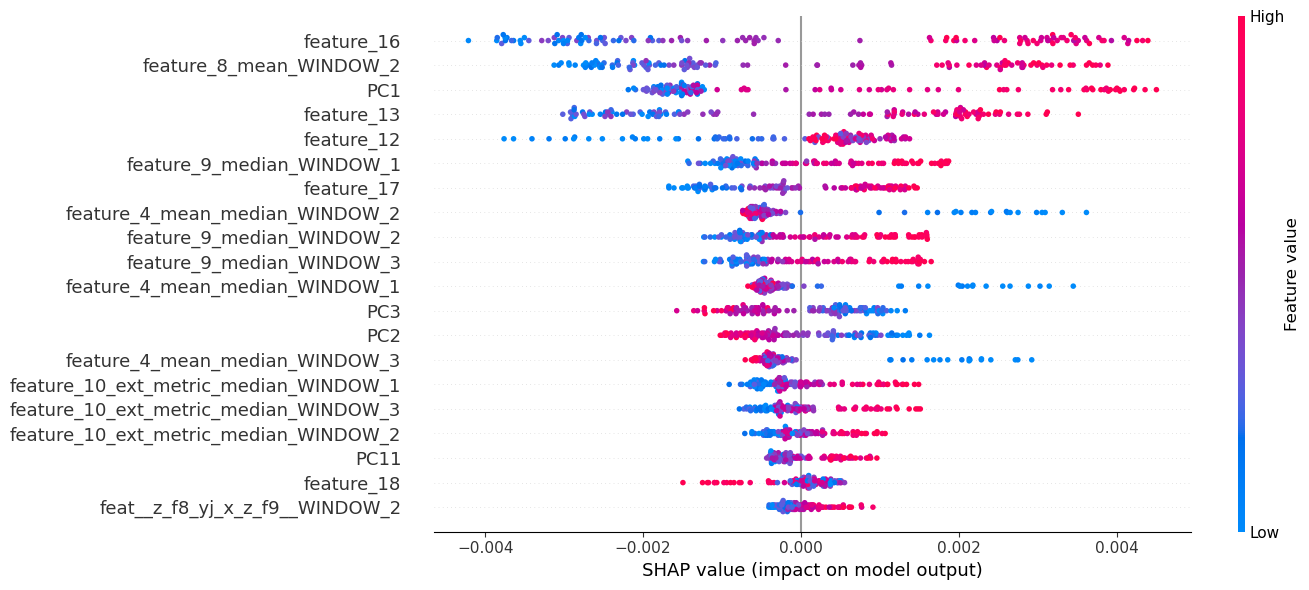

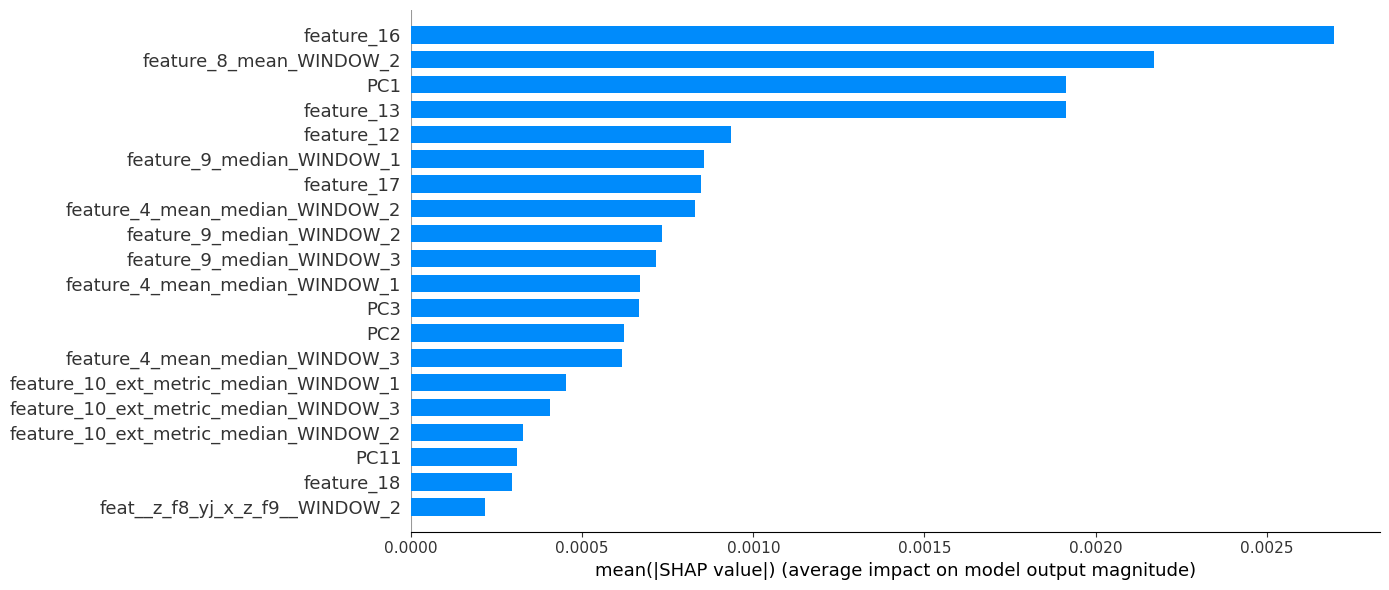

In [11]:
# --- SHAP for your final Random Forest model (regression) ---
# Assumes:
#   rf_final   -> trained RandomForestRegressor
#   X_selected -> stability-selected DataFrame of features used for training

X_explain = X_selected.copy()

explainer = shap.Explainer(rf_final, X_explain)
shap_values = explainer(X_explain)

# Make matplotlib a bit more forgiving about label space
plt.rcParams["figure.autolayout"] = True

# --- Global importance (beeswarm) ---
shap.summary_plot(
    shap_values,
    X_explain,
    max_display=20,          # reduce if labels are long
    plot_size=(14, 6),       # <-- THIS is the key control
    show=True
)

# --- Global importance (bar) ---
shap.summary_plot(
    shap_values,
    X_explain,
    plot_type="bar",
    max_display=20,
    plot_size=(14, 6),
    show=True
)

## Contextual Anomaly Scoring

The anomaly scoring block provides diagnostic prioritization, not automated failure labeling. PCA-space anomaly scores identify unusual operating states, while residual anomaly scores identify runs where the final model disagrees strongly with the observed target.

Runs with high anomaly scores are candidates for human review. They may reflect missing drivers, unusual combinations of conditions, measurement artifacts, or process states that are underrepresented in the historical data.


In [12]:
# ------------------------------------------------------------
# Anomaly scoring (VALID use-cases):
#   1) Input-space anomaly in PCA space (model-free): Mahalanobis + IsolationForest
#   2) Model-disagreement anomaly (diagnostic only): abs residual z-score
#
# Assumes you already have:
#   - df         : your filtered dataset (rows = runs)
#   - score_df   : PCA scores DataFrame with columns PC1..PCn (same index as df)
#   - model_df   : your prepared training data (optional for joining)
#   - rf_final   : trained regression model on X_selected (optional; used for residual anomaly)
#   - X_selected : stability-selected feature matrix used to train rf_final (optional; aligned index)
#   - target_col : string target name (set below)
# ------------------------------------------------------------

# ===== USER CONTROLS =====
target_col = TARGET_COL
pcs_for_anomaly = [f"PC{i}" for i in range(1, 17)]   # choose PCs used for anomaly scoring (must exist in score_df)
iso_contamination = "auto"                           # or e.g. 0.1 if you want a fixed assumed fraction
random_state = 0
# =========================

# --- Validate and assemble PC matrix ---
pcs_for_anomaly = [pc for pc in pcs_for_anomaly if pc in score_df.columns]
if len(pcs_for_anomaly) == 0:
    raise ValueError("No PCs found for anomaly scoring. Check pcs_for_anomaly vs score_df columns.")

S = score_df[pcs_for_anomaly].copy()
S = S.replace([np.inf, -np.inf], np.nan)
S = S.fillna(S.median(numeric_only=True))

# ------------------------------------------------------------
# 1) Input-space anomaly score: Robust Mahalanobis distance (MinCovDet)
# ------------------------------------------------------------
mcd = MinCovDet(random_state=random_state).fit(S.values)
md2 = mcd.mahalanobis(S.values)          # squared robust Mahalanobis distance
md = np.sqrt(md2)

# Normalize to z-score for easier thresholding
md_z = (md - md.mean()) / (md.std(ddof=0) + 1e-12)

# ------------------------------------------------------------
# 2) Input-space anomaly score: Isolation Forest in PC space
# ------------------------------------------------------------
iso = IsolationForest(
    n_estimators=500,
    contamination=iso_contamination,
    random_state=random_state
).fit(S.values)

# sklearn: higher decision_function = more normal; invert so higher = more anomalous
iso_anom = -iso.decision_function(S.values)

# Normalize to z-score
iso_z = (iso_anom - iso_anom.mean()) / (iso_anom.std(ddof=0) + 1e-12)

# ------------------------------------------------------------
# 3) Model-disagreement anomaly (diagnostic only): absolute residual z-score
#    (Optional; only computed if rf_final and X_selected are available)
# ------------------------------------------------------------
resid_abs = None
resid_abs_z = None

if "rf_final" in globals() and "X_selected" in globals():
    # Ensure alignment
    common_idx = S.index.intersection(X_selected.index)
    if len(common_idx) >= 5 and target_col in df.columns:
        y_true = pd.to_numeric(df.loc[common_idx, target_col], errors="coerce")
        Xp = X_selected.loc[common_idx]
        y_pred = pd.Series(rf_final.predict(Xp), index=common_idx)

        resid = (y_true - y_pred)
        resid_abs = resid.abs()

        # Robust-ish z using MAD (more stable with small N)
        med = np.nanmedian(resid_abs)
        mad = np.nanmedian(np.abs(resid_abs - med)) + 1e-12
        resid_abs_z = (resid_abs - med) / (1.4826 * mad)

# ------------------------------------------------------------
# Assemble anomaly table
# ------------------------------------------------------------
id_cols = [c for c in ["run_id", "run_start_date", "unit_label", "group_label"] if c in df.columns]

anom_df = pd.DataFrame(index=S.index)
if id_cols:
    anom_df = pd.concat([df.loc[S.index, id_cols], anom_df], axis=1)

anom_df["mdistance"] = md
anom_df["mdistance_z"] = md_z
anom_df["iso_anomaly"] = iso_anom
anom_df["iso_anomaly_z"] = iso_z

# Combined input anomaly score (simple average of z-scores)
anom_df["input_anomaly_score_z"] = (anom_df["mdistance_z"] + anom_df["iso_anomaly_z"]) / 2.0

# Optional residual anomaly columns
if resid_abs is not None:
    anom_df.loc[resid_abs.index, "y_true"] = pd.to_numeric(df.loc[resid_abs.index, target_col], errors="coerce")
    anom_df.loc[resid_abs.index, "y_pred"] = y_pred
    anom_df.loc[resid_abs.index, "abs_residual"] = resid_abs
    anom_df.loc[resid_abs.index, "abs_residual_z"] = resid_abs_z

    # Combined diagnostic score: input anomaly + residual anomaly (diagnostic only)
    anom_df["diagnostic_anomaly_score_z"] = anom_df["input_anomaly_score_z"]
    anom_df.loc[resid_abs.index, "diagnostic_anomaly_score_z"] = (
        anom_df.loc[resid_abs.index, "input_anomaly_score_z"] + anom_df.loc[resid_abs.index, "abs_residual_z"]
    ) / 2.0

# Rank (higher = more anomalous)
rank_col = "diagnostic_anomaly_score_z" if "diagnostic_anomaly_score_z" in anom_df.columns else "input_anomaly_score_z"
anom_df = anom_df.sort_values(rank_col, ascending=False)

# ------------------------------------------------------------
# Output: show top anomalous runs
# ------------------------------------------------------------
print(f"PCs used: {pcs_for_anomaly}")
print(f"Ranking by: {rank_col}")
display(anom_df.head(15))

# ------------------------------------------------------------
# OPTIONAL: export to global_model_outputs (if fp is defined)
# ------------------------------------------------------------
# from pathlib import Path
# out_dir = GLOBAL_OUTPUT_DIR
# out_dir.mkdir(parents=True, exist_ok=True)
# anom_df.to_csv(out_dir / "anomaly_scores.csv", index=False)
# print(f"\nExported: {out_dir / 'anomaly_scores.csv'}")

PCs used: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16']
Ranking by: diagnostic_anomaly_score_z


,run_id,run_start_date,unit_label,group_label,mdistance,mdistance_z,iso_anomaly,iso_anomaly_z,input_anomaly_score_z,y_true,y_pred,abs_residual,abs_residual_z,diagnostic_anomaly_score_z
71,RUN_072,2025-08-07,GR06,group_1,18.773361,5.747959,0.086014,4.339703,5.043831,0.00000,0.004626,0.004626,0.507560,2.775695
15,RUN_016,2025-02-20,GR04,group_1,5.698978,0.282127,-0.019499,1.021741,0.651934,0.07266,0.056372,0.016288,4.529999,2.590966
93,RUN_094,2025-10-12,GR04,group_2,11.858698,2.857238,0.026151,2.457260,2.657249,0.00000,0.008995,0.008995,2.014709,2.335979
6,RUN_007,2025-01-24,GR01,group_3,3.430803,-0.666099,-0.072450,-0.643388,-0.654744,0.07054,0.054348,0.016192,4.496705,1.920981
34,RUN_035,2025-04-18,GR05,group_2,15.338044,4.311802,0.018732,2.223944,3.267873,0.02878,0.025619,0.003161,0.002408,1.635140
38,RUN_039,2025-04-30,GR03,group_1,4.432044,-0.247523,-0.057588,-0.176028,-0.211776,0.00073,0.013834,0.013104,3.431796,1.610010
114,RUN_115,2025-12-14,GR01,group_1,5.932128,0.379597,-0.031773,0.635766,0.507681,0.00088,0.011675,0.010795,2.635530,1.571606
24,RUN_025,2025-03-19,GR01,group_1,5.732600,0.296183,-0.063297,-0.355552,-0.029685,0.06643,0.054485,0.011945,3.031925,1.501120
25,RUN_026,2025-03-22,GR02,group_1,6.357393,0.557382,-0.017446,1.086281,0.821831,0.05457,0.045220,0.009350,2.136877,1.479354
0,RUN_001,2025-01-06,GR01,group_3,14.630714,4.016098,0.054096,3.336022,3.676060,0.04075,0.040856,0.000106,-1.051371,1.312345


## Optional Classification View

The classification branch reframes the continuous target as a low-versus-high outcome state. This answers a different question from regression: not “how much did the outcome change?” but “which conditions distinguish lower and higher outcome states?”

The same stability-selection philosophy is applied here. Logistic Elastic Net contributes stable linear class structure, Random Forest contributes nonlinear class structure, and only repeatedly selected features are retained for the final classifier.


In [15]:
# ------------------------------------------------------------
# Stability-selected union feature selection for classification
#   - Logistic Elastic Net captures stable linear/global class structure.
#   - Random Forest classifier importance captures nonlinear and interaction-driven class structure.
#   - Features are retained only if the union selector repeatedly selects them
#     across resampled folds.
# ------------------------------------------------------------

# ===== USER CONTROLS =====
target_col = TARGET_COL
q = 0.50                 # binary median split (LOW <= median, HIGH > median)
n_splits = 5             # stratified CV folds
random_state = 0

# Base union selector controls
CLF_ENET_COEF_TOL = 1e-8
CLF_RF_SELECTOR_N_ESTIMATORS = 300
CLF_RF_SELECTOR_MIN_SAMPLES_LEAF = 2
CLF_RF_SELECTOR_TOP_K = 25
CLF_RF_SELECTOR_MIN_IMPORTANCE = 0.005

# Stability selection controls
CLF_STABILITY_N_SPLITS = 5
CLF_STABILITY_N_REPEATS = 2
CLF_STABILITY_MIN_SELECTION_RATE = 0.80
CLF_STABILITY_FALLBACK_TOP_K = 10
# =========================

# --- Split X / y (numeric target) ---
y_cont = pd.to_numeric(model_df[target_col], errors="coerce")
X = model_df.drop(columns=[target_col]).copy()

# Drop rows with missing target
mask = y_cont.notna()
X, y_cont = X.loc[mask], y_cont.loc[mask]

# --- Binary quantile binning ---
thr = y_cont.quantile(q)
y_bin = (y_cont > thr).astype(int)   # 0 = LOW, 1 = HIGH

print(f"Binary binning threshold at q={q:.2f}: {thr:.4f}")
print("Class counts (0=LOW, 1=HIGH):")
print(y_bin.value_counts().sort_index())


def _classification_preprocess(X_data):
    """Build preprocessing for numeric and categorical predictors."""
    num_cols = X_data.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X_data.columns if c not in num_cols]

    preprocess = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", drop=None, sparse_output=False), cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return preprocess, num_cols, cat_cols


def fit_classification_union_selector(X_train, y_train, random_state=0):
    """Fit one Logistic Elastic Net + RF union selector on the provided training data."""
    preprocess, num_cols, cat_cols = _classification_preprocess(X_train)

    min_class = int(y_train.value_counts().min())
    cv_inner = StratifiedKFold(
        n_splits=min(n_splits, min_class),
        shuffle=True,
        random_state=random_state,
    )

    logit_enet = LogisticRegressionCV(
        penalty="elasticnet",
        solver="saga",
        l1_ratios=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        Cs=np.logspace(-3, 3, 25),
        cv=cv_inner,
        scoring="roc_auc",
        max_iter=20000,
        n_jobs=1,
        refit=True,
    )

    pipe = Pipeline(steps=[("prep", preprocess), ("clf", logit_enet)])
    pipe.fit(X_train, y_train)

    feature_names = pipe.named_steps["prep"].get_feature_names_out()
    X_design = pd.DataFrame(
        pipe.named_steps["prep"].transform(X_train),
        columns=feature_names,
        index=X_train.index,
    )

    coef_s = pd.Series(pipe.named_steps["clf"].coef_.ravel(), index=feature_names)
    logit_ranked = coef_s.reindex(coef_s.abs().sort_values(ascending=False).index)
    selected_logit = logit_ranked.index[logit_ranked.abs() > CLF_ENET_COEF_TOL].tolist()

    rf_selector = RandomForestClassifier(
        n_estimators=CLF_RF_SELECTOR_N_ESTIMATORS,
        min_samples_leaf=CLF_RF_SELECTOR_MIN_SAMPLES_LEAF,
        max_features="sqrt",
        random_state=random_state,
        n_jobs=-1,
    )
    rf_selector.fit(X_design, y_train)

    rf_importance_s = pd.Series(
        rf_selector.feature_importances_,
        index=feature_names,
    ).sort_values(ascending=False)

    rf_selected_by_threshold = rf_importance_s[rf_importance_s >= CLF_RF_SELECTOR_MIN_IMPORTANCE].index.tolist()
    rf_selected_by_rank = rf_importance_s.head(min(CLF_RF_SELECTOR_TOP_K, len(rf_importance_s))).index.tolist()
    selected_rf = list(dict.fromkeys(rf_selected_by_threshold + rf_selected_by_rank))

    selected_union = list(dict.fromkeys(selected_logit + selected_rf))
    if not selected_union:
        selected_union = rf_importance_s.head(min(CLF_RF_SELECTOR_TOP_K, len(rf_importance_s))).index.tolist()

    return {
        "pipe": pipe,
        "feature_names": list(feature_names),
        "X_design": X_design,
        "coef_s": coef_s,
        "selected_logit": selected_logit,
        "rf_importance_s": rf_importance_s,
        "selected_rf": selected_rf,
        "selected_union": selected_union,
    }


def fit_classification_stability_selector(
    X_data,
    y_data,
    n_splits=CLF_STABILITY_N_SPLITS,
    n_repeats=CLF_STABILITY_N_REPEATS,
    min_selection_rate=CLF_STABILITY_MIN_SELECTION_RATE,
    random_state=0,
):
    """Run repeated fold-local union selection and keep only stable classifier features."""
    full_selector = fit_classification_union_selector(X_data, y_data, random_state=random_state)
    feature_names = full_selector["feature_names"]

    logit_counts = pd.Series(0, index=feature_names, dtype=float)
    rf_counts = pd.Series(0, index=feature_names, dtype=float)
    union_counts = pd.Series(0, index=feature_names, dtype=float)
    rf_importance_sum = pd.Series(0.0, index=feature_names, dtype=float)
    rf_importance_sq_sum = pd.Series(0.0, index=feature_names, dtype=float)

    n_iterations = 0
    for repeat in range(n_repeats):
        cv = StratifiedKFold(n_splits=min(n_splits, int(y_data.value_counts().min())), shuffle=True, random_state=random_state + repeat)
        for train_idx, _ in cv.split(X_data, y_data):
            X_fold = X_data.iloc[train_idx]
            y_fold = y_data.iloc[train_idx]
            selector = fit_classification_union_selector(X_fold, y_fold, random_state=random_state + repeat)

            logit_counts.loc[logit_counts.index.intersection(selector["selected_logit"])] += 1
            rf_counts.loc[rf_counts.index.intersection(selector["selected_rf"])] += 1
            union_counts.loc[union_counts.index.intersection(selector["selected_union"])] += 1

            fold_importance = selector["rf_importance_s"].reindex(feature_names).fillna(0.0)
            rf_importance_sum += fold_importance
            rf_importance_sq_sum += fold_importance ** 2
            n_iterations += 1

    if n_iterations == 0:
        raise RuntimeError("No classification stability-selection iterations were run.")

    mean_rf_importance = rf_importance_sum / n_iterations
    var_rf_importance = (rf_importance_sq_sum / n_iterations) - (mean_rf_importance ** 2)
    std_rf_importance = np.sqrt(np.maximum(var_rf_importance, 0.0))

    summary = pd.DataFrame({
        "logit_selection_rate": logit_counts / n_iterations,
        "rf_selection_rate": rf_counts / n_iterations,
        "union_selection_rate": union_counts / n_iterations,
        "mean_rf_importance": mean_rf_importance,
        "std_rf_importance": std_rf_importance,
        "full_data_logit_coef": full_selector["coef_s"].reindex(feature_names),
        "full_data_rf_importance": full_selector["rf_importance_s"].reindex(feature_names),
    })
    summary["stable_selected"] = summary["union_selection_rate"] >= min_selection_rate

    stable_names = summary.index[summary["stable_selected"]].tolist()
    if not stable_names:
        stable_names = (
            summary.sort_values(["union_selection_rate", "mean_rf_importance"], ascending=False)
            .head(min(CLF_STABILITY_FALLBACK_TOP_K, len(summary)))
            .index
            .tolist()
        )
        summary.loc[stable_names, "stable_selected"] = True
        print(
            "No classification features met the stability threshold; "
            f"falling back to the top {len(stable_names)} by selection rate / RF importance."
        )

    summary = summary.sort_values(
        ["stable_selected", "union_selection_rate", "mean_rf_importance"],
        ascending=[False, False, False],
    )

    return {
        "full_selector": full_selector,
        "feature_summary": summary,
        "stable_feature_names": stable_names,
        "n_iterations": n_iterations,
    }


print(f"\nRows: {X.shape[0]} | Predictors: {X.shape[1]}")
clf_stability_result = fit_classification_stability_selector(X, y_bin, random_state=random_state)

clf_full_selector = clf_stability_result["full_selector"]
stable_feature_summary_clf = clf_stability_result["feature_summary"]
stable_selected_feature_names_clf = clf_stability_result["stable_feature_names"]
selected_feature_names_clf = stable_selected_feature_names_clf

# Keep compatibility names for downstream code and interpretation.
selected_feature_names_logit = clf_full_selector["selected_logit"]
selected_feature_names_rf_clf = clf_full_selector["selected_rf"]
feature_selection_summary_clf = stable_feature_summary_clf
X_design_clf = clf_full_selector["X_design"]
X_selected_clf = X_design_clf[stable_selected_feature_names_clf].copy()
pipe_clf = clf_full_selector["pipe"]

print("\nFull-data Logistic Elastic Net chosen hyperparameters:")
print(f"  best C:        {pipe_clf.named_steps['clf'].C_[0]}")
print(f"  best l1_ratio: {pipe_clf.named_steps['clf'].l1_ratio_[0]}")

print("\nClassification stability selection summary:")
print(f"  Stability folds:             {clf_stability_result['n_iterations']}")
print(f"  Min selection rate:          {CLF_STABILITY_MIN_SELECTION_RATE:.0%}")
print(f"  Full-data Logistic EN:       {len(selected_feature_names_logit)} / {len(X_design_clf.columns)}")
print(f"  Full-data RF classifier:     {len(selected_feature_names_rf_clf)} / {len(X_design_clf.columns)}")
print(f"  Stable union selected:       {len(stable_selected_feature_names_clf)} / {len(X_design_clf.columns)}")

display(stable_feature_summary_clf.head(40))

print("\nShapes for downstream classification modeling:")
print("  X_design_clf:", X_design_clf.shape)
print("  X_selected_clf:", X_selected_clf.shape)


Binary binning threshold at q=0.50: 0.0213
Class counts (0=LOW, 1=HIGH):
target_metric_primary
0    60
1    60
Name: count, dtype: int64

Rows: 120 | Predictors: 77

Full-data Logistic Elastic Net chosen hyperparameters:
  best C:        17.78279410038923
  best l1_ratio: 0.1

Classification stability selection summary:
  Stability folds:             10
  Min selection rate:          80%
  Full-data Logistic EN:       80 / 88
  Full-data RF classifier:     57 / 88
  Stable union selected:       52 / 88


,logit_selection_rate,rf_selection_rate,union_selection_rate,mean_rf_importance,std_rf_importance,full_data_logit_coef,full_data_rf_importance,stable_selected
feature_13,1.0,1.0,1.0,0.088132,0.008988,2.717899,0.094137,True
feature_16,1.0,1.0,1.0,0.079418,0.013441,0.338433,0.083391,True
feature_8_mean_WINDOW_2,0.9,1.0,1.0,0.072359,0.011844,1.003228,0.073024,True
feature_12,0.9,1.0,1.0,0.058839,0.010617,1.925148,0.063237,True
PC1,1.0,1.0,1.0,0.058287,0.007997,1.302941,0.058572,True
feature_17,0.9,1.0,1.0,0.034868,0.009856,0.713684,0.033023,True
PC4,1.0,1.0,1.0,0.027470,0.010543,1.249001,0.028483,True
PC3,0.8,1.0,1.0,0.025918,0.007313,-1.253908,0.017968,True
feature_10_ext_metric_median_WINDOW_2,0.9,1.0,1.0,0.024741,0.003210,0.726430,0.026203,True
feature_10_ext_metric_median_WINDOW_3,0.7,1.0,1.0,0.024619,0.003801,0.666696,0.025761,True



Shapes for downstream classification modeling:
  X_design_clf: (120, 88)
  X_selected_clf: (120, 52)


In [16]:
# Random Forest classification with stability-selected union features refit inside each CV fold.
target_col = TARGET_COL
q = 0.50
n_splits = 5
n_repeats = 1
CV_CLF_STABILITY_N_REPEATS = 1
CV_CLF_STABILITY_MIN_SELECTION_RATE = CLF_STABILITY_MIN_SELECTION_RATE

y_cont_full = pd.to_numeric(model_df[target_col], errors="coerce")
X_full = model_df.drop(columns=[target_col]).copy()

mask = y_cont_full.notna()
X_full, y_cont_full = X_full.loc[mask], y_cont_full.loc[mask]

thr = y_cont_full.quantile(q)
y_full = (y_cont_full > thr).astype(int)

roc_auc_scores = []
bal_acc_scores = []
selected_counts = []

for seed in range(n_repeats):
    cv_outer = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=seed,
    )

    for train_idx, test_idx in cv_outer.split(X_full, y_full):
        X_train, X_test = X_full.iloc[train_idx], X_full.iloc[test_idx]
        y_train, y_test = y_full.iloc[train_idx], y_full.iloc[test_idx]

        selector_result = fit_classification_stability_selector(
            X_train,
            y_train,
            n_splits=CLF_STABILITY_N_SPLITS,
            n_repeats=CV_CLF_STABILITY_N_REPEATS,
            min_selection_rate=CV_CLF_STABILITY_MIN_SELECTION_RATE,
            random_state=seed,
        )
        selector_pipe = selector_result["full_selector"]["pipe"]
        selected_names = selector_result["stable_feature_names"]

        feature_names = selector_pipe.named_steps["prep"].get_feature_names_out()
        X_train_design = pd.DataFrame(
            selector_pipe.named_steps["prep"].transform(X_train),
            columns=feature_names,
            index=X_train.index,
        )
        X_test_design = pd.DataFrame(
            selector_pipe.named_steps["prep"].transform(X_test),
            columns=feature_names,
            index=X_test.index,
        )

        X_train_sel = X_train_design[selected_names].copy()
        X_test_sel = X_test_design[selected_names].copy()
        selected_counts.append(len(selected_names))

        rf = RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=2,
            max_features="sqrt",
            random_state=seed,
        )

        rf.fit(X_train_sel, y_train)

        y_prob = rf.predict_proba(X_test_sel)[:, 1]
        y_pred = rf.predict(X_test_sel)

        roc_auc_scores.append(roc_auc_score(y_test, y_prob))
        bal_acc_scores.append(balanced_accuracy_score(y_test, y_pred))

roc_auc_scores = np.array(roc_auc_scores)
bal_acc_scores = np.array(bal_acc_scores)

print("Random Forest classification performance with fold-local stability-selected union features:")
print(f"ROC AUC: mean={roc_auc_scores.mean():.3f}, std={roc_auc_scores.std():.3f}")
print("ROC AUC quantiles:", np.quantile(roc_auc_scores, [0.1, 0.25, 0.5, 0.75, 0.9]))
print(f"Balanced Accuracy: mean={bal_acc_scores.mean():.3f}, std={bal_acc_scores.std():.3f}")
print("Balanced Accuracy quantiles:", np.quantile(bal_acc_scores, [0.1, 0.25, 0.5, 0.75, 0.9]))
print(
    "Selected feature count: "
    f"median={np.median(selected_counts):.0f}, range=({np.min(selected_counts)}, {np.max(selected_counts)})"
)


Random Forest classification performance with fold-local stability-selected union features:
ROC AUC: mean=0.919, std=0.061
ROC AUC quantiles: [0.84861111 0.90277778 0.93055556 0.95833333 0.97916667]
Balanced Accuracy: mean=0.867, std=0.085
Balanced Accuracy quantiles: [0.775      0.875      0.875      0.91666667 0.94166667]
Selected feature count: median=56, range=(43, 63)


In [17]:
# Fit the final classification model on the stability-selected union feature matrix.
# X_selected_clf is produced by the classification stability-selection block above.
if "X_selected_clf" not in globals():
    raise RuntimeError("X_selected_clf not found. Run the classification stability-selection block first.")

rf_clf_final = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=0,
)
rf_clf_final.fit(X_selected_clf, y_bin)
print(f"Final RF classifier fit on stability-selected X_selected_clf with shape {X_selected_clf.shape}.")


Final RF classifier fit on stability-selected X_selected_clf with shape (120, 52).


## Explaining High vs Low Outcome States

The classifier explanation blocks show which selected features push predictions toward the high or low outcome class. SHAP provides a global view of class-driving features, while LIME provides a local explanation for a single run.

These explanations should be used as investigation aids. They can help identify candidate mechanisms or unusual cases, but they should be interpreted alongside process knowledge and the regression-based global model.


In [ ]:
# --- SHAP for your FINAL Random Forest CLASSIFIER (binary) ---
# Assumes you already have:
#   rf_clf_final     -> trained RandomForestClassifier
#   X_selected_clf   -> stability-selected DataFrame of features used to train rf_clf_final
#   fp               -> original csv filepath (for output folder), optional but recommended

X_explain = X_selected_clf.copy()

explainer = shap.TreeExplainer(rf_clf_final)
shap_vals = explainer.shap_values(X_explain)

# ------------------------------------------------------------
# Normalize SHAP output to a 2D matrix for the positive class (class 1)
# ------------------------------------------------------------
if isinstance(shap_vals, list):
    # Common older behavior: list of [class0, class1]
    shap_pos = shap_vals[1]
else:
    shap_pos = shap_vals

shap_pos = np.asarray(shap_pos)

if shap_pos.ndim == 3:
    # Newer behavior: (n_samples, n_features, n_classes)
    shap_pos = shap_pos[:, :, 1]   # select class 1

if shap_pos.ndim != 2:
    raise ValueError(f"Unexpected SHAP array shape after processing: {shap_pos.shape}")

# ------------------------------------------------------------
# Plots (class 1: HIGH)
# NOTE: use plot_size to avoid narrow/tall issues
# ------------------------------------------------------------
shap.summary_plot(
    shap_pos,
    X_explain,
    max_display=20,
    plot_size=(14, 6)
)

shap.summary_plot(
    shap_pos,
    X_explain,
    plot_type="bar",
    max_display=20,
    plot_size=(14, 6)
)

# ------------------------------------------------------------
# Export SHAP values (class 1) to global_model_outputs
# ------------------------------------------------------------
out_dir = GLOBAL_OUTPUT_DIR
out_dir.mkdir(parents=True, exist_ok=True)

shap_df = pd.DataFrame(shap_pos, columns=X_explain.columns, index=X_explain.index)
shap_df.to_csv(out_dir / "shap_values_class1.csv", index=False)

# Optional: mean |SHAP| importance table
imp = shap_df.abs().mean(axis=0).sort_values(ascending=False)
imp.to_csv(out_dir / "shap_importance_class1.csv", header=["mean_abs_shap"])

print(f"Exported:\n  {out_dir / 'shap_values_class1.csv'}\n  {out_dir / 'shap_importance_class1.csv'}")

In [ ]:
# ------------------------------------------------------------
# Contextual anomaly detection (VALID use-cases):
#   A) Input-space anomaly: unusual conditions in PCA space (model-free)
#   B) Contextual anomaly: classifier says HIGH but observed LOW (and vice versa)
#   C) Uncertainty: near-boundary probabilities (diagnostic, not failure prediction)
#
# Requires:
#   score_df          : PCA scores with PC columns
#   y_bin             : binary labels aligned to runs (0=LOW, 1=HIGH)
#   rf_clf_final      : trained RF classifier
#   X_selected_clf    : stability-selected feature matrix used for classifier (aligned index)
#   df                : original filtered df (optional for identifiers)
#   fp                : original filepath (optional; for export folder)
# ------------------------------------------------------------

# ===== USER CONTROLS =====
pcs_for_context = [f"PC{i}" for i in range(1, 17)]   # PCs used for input anomaly scoring
prob_margin = 0.10    # "near boundary" if |p(HIGH)-0.5| <= margin
random_state = 0
do_cv_probs = True    # True = use out-of-fold probabilities (recommended). False = use in-sample probs.
n_splits = 5          # for out-of-fold probabilities
# =========================

# ---- Align indices ----
idx = X_selected_clf.index.intersection(y_bin.index)
Xc = X_selected_clf.loc[idx].copy()
y = y_bin.loc[idx].copy()

# ---- Predicted probabilities for HIGH (class 1) ----
if do_cv_probs:
    # Out-of-fold probabilities reduce optimism (recommended for diagnostics)
    oof_prob = pd.Series(index=idx, dtype=float)
    cv = StratifiedKFold(n_splits=min(n_splits, int(y.value_counts().min())), shuffle=True, random_state=random_state)
    for tr, te in cv.split(Xc, y):
        rf_tmp = rf_clf_final.__class__(**rf_clf_final.get_params())
        rf_tmp.fit(Xc.iloc[tr], y.iloc[tr])
        oof_prob.iloc[te] = rf_tmp.predict_proba(Xc.iloc[te])[:, 1]
    p_high = oof_prob
else:
    # In-sample probabilities (optimistic; OK for exploration)
    p_high = pd.Series(rf_clf_final.predict_proba(Xc)[:, 1], index=idx)

pred_class = (p_high >= 0.5).astype(int)

# ---- Input-space anomaly in PCA space ----
pcs_for_context = [pc for pc in pcs_for_context if pc in score_df.columns]
if len(pcs_for_context) == 0:
    raise ValueError("No PCs found for contextual anomaly scoring. Check pcs_for_context vs score_df columns.")

S = score_df.loc[idx, pcs_for_context].copy()
S = S.replace([np.inf, -np.inf], np.nan).fillna(S.median(numeric_only=True))

# Robust Mahalanobis distance (structure anomaly)
mcd = MinCovDet(random_state=random_state).fit(S.values)
md2 = mcd.mahalanobis(S.values)
md = np.sqrt(md2)
md_z = (md - md.mean()) / (md.std(ddof=0) + 1e-12)

# Isolation Forest anomaly (structure anomaly)
iso = IsolationForest(n_estimators=500, contamination="auto", random_state=random_state).fit(S.values)
iso_anom = -iso.decision_function(S.values)
iso_z = (iso_anom - iso_anom.mean()) / (iso_anom.std(ddof=0) + 1e-12)

input_anom_z = (md_z + iso_z) / 2.0

# ---- Contextual anomaly signals ----
misclass_flag = (pred_class != y).astype(int)  # 1 = predicted opposite of observed
confidence = (p_high - 0.5).abs()              # distance from decision boundary
uncertainty = 0.5 - confidence                 # higher = more uncertain
near_boundary_flag = (confidence <= prob_margin).astype(int)

# "Strong contradiction" = misclassified AND confident
# (these are the runs that most deserve review, NOT "failures")
strong_contradiction = ((misclass_flag == 1) & (confidence >= prob_margin)).astype(int)

# Combined contextual score (diagnostic ranking only):
# - reward: misclassification (context mismatch)
# - reward: input anomaly (unusual conditions)
# - reward: confidence (if it's confidently wrong, it's more interesting)
context_score = (
    1.0 * misclass_flag +
    0.5 * strong_contradiction +
    0.5 * input_anom_z +
    0.25 * confidence
)

# ---- Assemble report ----
id_cols = [c for c in ["run_id", "run_start_date", "unit_label", "group_label"] if c in df.columns]
report = pd.DataFrame(index=idx)

if id_cols:
    report = pd.concat([df.loc[idx, id_cols], report], axis=1)

report["y_bin_observed"] = y
report["p_high"] = p_high
report["y_bin_pred"] = pred_class

report["misclass_flag"] = misclass_flag
report["near_boundary_flag"] = near_boundary_flag
report["strong_contradiction_flag"] = strong_contradiction

report["mdistance_z"] = md_z
report["iso_anomaly_z"] = iso_z
report["input_anomaly_score_z"] = input_anom_z

report["confidence"] = confidence
report["contextual_anomaly_score"] = context_score

# Sort: highest contextual anomaly first
report = report.sort_values("contextual_anomaly_score", ascending=False)

print(f"Using {'out-of-fold' if do_cv_probs else 'in-sample'} probabilities.")
print(f"Boundary margin: ±{prob_margin:.2f} around 0.5")
display(report.head(15))

# ---- Optional export ----
out_dir = GLOBAL_OUTPUT_DIR
out_dir.mkdir(parents=True, exist_ok=True)
report.to_csv(out_dir / "contextual_anomaly_report.csv", index=False)
print(f"\nExported: {out_dir / 'contextual_anomaly_report.csv'}")

Run = 'RUN_089'
Observed class = HIGH
Predicted P(LOW)=0.341, P(HIGH)=0.659  -> predicted=HIGH


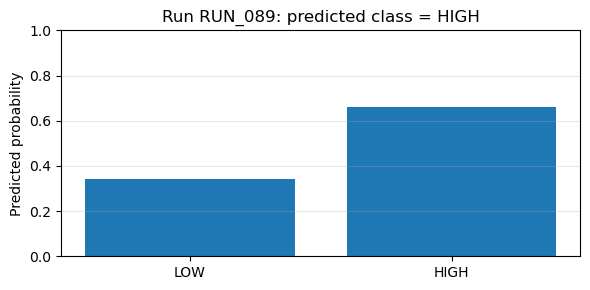

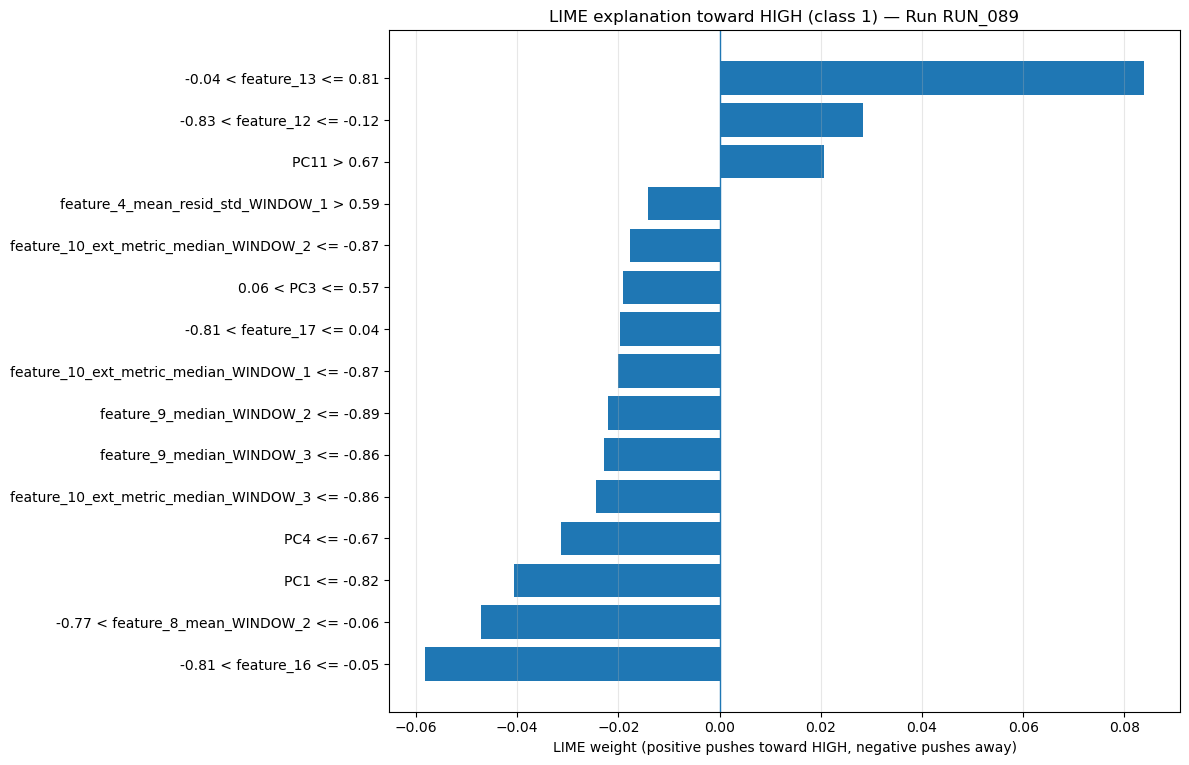

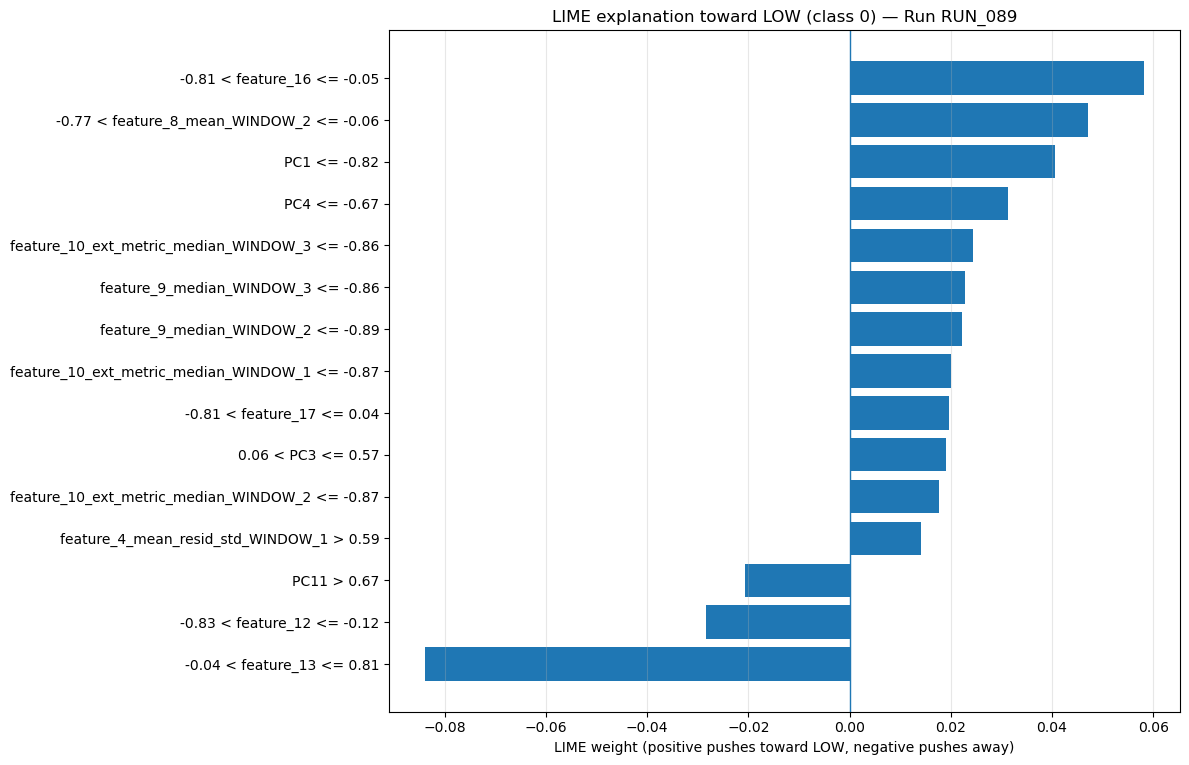

In [21]:
# --- LIME local explanation + visualizations (binary RF classifier) ---

# ---------------------------
# USER CONTROLS
# ---------------------------
run_to_explain = "RUN_089"       # <-- set Run ID
label_names = ["LOW", "HIGH"]  # class 0, class 1
num_features = 15
random_state = 0

plot_both_classes = False      # True -> also plot LOW explanation
# ---------------------------

# ---- Checks / alignment ----
if "run_id" not in df.columns:
    raise ValueError("Column 'Run' not found in df.")

X_train = X_selected_clf.copy()
idx = X_train.index

# Find the row index for this Run among rows used by the classifier
run_series = df.loc[idx, "run_id"].astype(str)
matches = run_series.index[run_series == str(run_to_explain)].tolist()
if len(matches) == 0:
    raise ValueError(f"Run {run_to_explain!r} not found among classifier rows (X_selected_clf).")
if len(matches) > 1:
    print(f"Warning: {len(matches)} rows match Run={run_to_explain!r}. Using the first.")

row_idx = matches[0]
x0 = X_train.loc[row_idx].values

# >>> REQUIRED EDIT: get observed class <<<
y_obs = y_bin.loc[row_idx]

# ---- Predict with feature names preserved (avoids sklearn warning) ----
def predict_proba_with_names(X_np):
    X_df = pd.DataFrame(X_np, columns=X_train.columns)
    return rf_clf_final.predict_proba(X_df)

p = predict_proba_with_names(X_train.loc[[row_idx]].values)[0]
pred_label = int(p[1] >= 0.5)

print(f"Run = {run_to_explain!r}")
print(f"Observed class = {label_names[int(y_obs)]}")
print(f"Predicted P(LOW)={p[0]:.3f}, P(HIGH)={p[1]:.3f}  -> predicted={label_names[pred_label]}")

# ---- Build LIME explainer ----
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=label_names,
    mode="classification",
    discretize_continuous=True,
    random_state=random_state
)

# Force both labels so exp.as_list(label=1) always exists
exp = explainer.explain_instance(
    data_row=x0,
    predict_fn=predict_proba_with_names,
    num_features=min(num_features, X_train.shape[1]),
    labels=(0, 1)
)

# ---- Convert LIME lists to DataFrames for plotting ----
lime_high = pd.DataFrame(exp.as_list(label=1), columns=["feature_rule", "weight"])
lime_low  = pd.DataFrame(exp.as_list(label=0), columns=["feature_rule", "weight"])

# For readability, plot in ascending order so the biggest bars end up on top
lime_high = lime_high.sort_values("weight")
lime_low  = lime_low.sort_values("weight")

# ============================================================
# VISUALIZATION 1: predicted probabilities bar
# ============================================================
plt.figure(figsize=(6, 3))
plt.bar(label_names, [p[0], p[1]])
plt.ylim(0, 1)
plt.ylabel("Predicted probability")
plt.title(f"Run {run_to_explain}: predicted class = {label_names[pred_label]}")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# ============================================================
# VISUALIZATION 2: LIME contributions toward HIGH
# ============================================================
plt.figure(figsize=(12, 0.45 * len(lime_high) + 1))
plt.barh(lime_high["feature_rule"], lime_high["weight"])
plt.axvline(0, linewidth=1)
plt.xlabel("LIME weight (positive pushes toward HIGH, negative pushes away)")
plt.title(f"LIME explanation toward HIGH (class 1) — Run {run_to_explain}")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# LIME contributions toward LOW (always show)
# ============================================================
plt.figure(figsize=(12, 0.45 * len(lime_low) + 1))
plt.barh(lime_low["feature_rule"], lime_low["weight"])
plt.axvline(0, linewidth=1)
plt.xlabel("LIME weight (positive pushes toward LOW, negative pushes away)")
plt.title(f"LIME explanation toward LOW (class 0) — Run {run_to_explain}")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Optional Drift Visualization In The Global Reference Frame

Even though the rolling notebook is responsible for local regime detection, it can still be useful to visualize long-horizon drift in global-model variables such as PCs or stable selected features.

If drift visualization is added or enabled, it should be treated as a descriptive trend tool rather than a formal control chart. The purpose is to connect local regime behavior back to broader structural axes in the global model, especially when a principal component or stable feature shows directional movement over time.


## Reading This Notebook With The Rolling Analysis

The two notebooks are meant to be read together. The rolling analysis asks when and how local relationships change. The global model asks which features remain consistently important despite those changes.

Features that appear both in local rolling driver shifts and in the global stable feature set deserve special attention. Local-only features may be regime-specific triggers, while global-only features may represent persistent background constraints or cross-regime operating conditions.
